In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [249]:
# Set the default font family to Helvetica for all plots
plt.rcParams['font.family'] = 'sans-serif'

# Optional: You can also set other global font parameters like size if needed
plt.rcParams['font.size'] = 14  # Default font size for text
plt.rcParams['axes.labelsize'] = 14  # Font size for axis labels
plt.rcParams['xtick.labelsize'] = 14  # Font size for x-tick labels
plt.rcParams['ytick.labelsize'] = 14  # Font size for y-tick labels
plt.rcParams['legend.fontsize'] = 14  # Font size for legends
plt.rcParams['figure.titlesize'] = 16  # Font size for figure titles

In [250]:
T = pd.read_csv('110625_GLUT3_processed.csv')
#T = pd.read_csv('110625_GLUT3_processed.csv')

In [251]:
T.file_name.unique()

array(['3920L_GLUT3_WGA594_0001.nd2', '3920L_GLUT3_WGA594_0002.nd2',
       '3920R_GLUT3_WGA594_0001.nd2', '3920R_GLUT3_WGA594_0002.nd2'],
      dtype=object)

In [264]:
# T = T.loc[T['file_name'] != '3963R_GLUT3_WGA594_0002.nd2']
# T = T.loc[T['file_name'] != '3963L_GLUT3_WGA594_0003.nd2']
# T.to_csv('102925_GLUT3_processed_expsettings.csv', index = False)
T = T.loc[T['file_name'] != '3920R_GLUT3_WGA594_0002.nd2']
T = T.loc[T['file_name'] != '3920L_GLUT3_WGA594_0001.nd2']
T.to_csv('110625_GLUT3_processed_expsettings.csv', index = False)

In [253]:
def analyze_glut_data(T):
    T = T.copy()
    T['Experimental_Condition'] = T['Experimental_Condition'].replace({'Experimental': 'Light Flicker', 'Control': 'Dark'})
    def find_col(df, candidates):
        for c in candidates:
            if c in df.columns:
                return c
        lm = {col.lower(): col for col in df.columns}
        for c in candidates:
            if c.lower() in lm:
                return lm[c.lower()]
        return None
    g_top = find_col(T, ['GLUT_Top_Integral','GLUT1_Top_Integral','GluT1_Top_Integral','GLUT_Top_Surface_Integral','GLUT1_Top_Surface_Integral'])
    g_bot = find_col(T, ['GLUT_Bottom_Integral','GLUT_Bot_Integral','GLUT1_Bottom_Integral','GLUT1_Bot_Integral','GluT1_Bottom_Integral','GluT1_Bot_Integral','GLUT_Bottom_Surface_Integral','GLUT_Bot_Surface_Integral','GLUT1_Bottom_Surface_Integral','GLUT1_Bot_Surface_Integral'])
    g_mid = find_col(T, ['GLUT_Middle_Integral','GLUT1_Middle_Integral','GluT1_Middle_Integral'])
    wga_top = find_col(T, ['WGA_Top_Integral','WGA_Top_Surface_Integral'])
    wga_bot = find_col(T, ['WGA_Bottom_Integral','WGA_Bot_Integral','WGA_Bottom_Surface_Integral','WGA_Bot_Surface_Integral'])
    resp_type = 'GLUT_membrane_over_wga_membrane'
    animal_ids = T['DJID'].unique()
    results = {'effect_size_noGFP': [], 'effect_size_GFP': [], 'genotype': [], 'sex': [], 'age': [], 'animal_id': [], 'n_cells': [], 'frac_GFP': []}
    def calculate_ratios(df, ratio_type):
        if df.empty:
            return []
        if ratio_type == 'GLUT_membrane_over_middle' and g_mid is not None and 'Length_um' in df.columns:
            denom = df[g_mid] * df['Length_um']
        else:
            denom = df[wga_top] + df[wga_bot]
        with np.errstate(divide='ignore', invalid='ignore'):
            ratios = (df[g_top] + df[g_bot]) / denom
            ratios = ratios.replace([np.inf, -np.inf], np.nan)
            return ratios.dropna().tolist()
    for a in animal_ids:
        T_this = T[T['DJID'] == a]
        genotype, sex, age = T_this.iloc[0][['Genotype', 'Sex', 'Age_Months']]
        N = len(T_this)
        T_dark = T_this[T_this['Experimental_Condition'] == 'Dark']
        T_light = T_this[T_this['Experimental_Condition'] == 'Light Flicker']
        if T_this['eGFP_Value'].dtype == bool:
            T_dark_GFP, T_dark_noGFP = T_dark[T_dark['eGFP_Value']], T_dark[~T_dark['eGFP_Value']]
            T_light_GFP, T_light_noGFP = T_light[T_light['eGFP_Value']], T_light[~T_light['eGFP_Value']]
        else:
            T_dark_GFP, T_dark_noGFP = T_dark[T_dark['eGFP_Value'] > 0], T_dark[T_dark['eGFP_Value'] == 0]
            T_light_GFP, T_light_noGFP = T_light[T_light['eGFP_Value'] > 0], T_light[T_light['eGFP_Value'] == 0]
        frac_GFP = (len(T_dark_GFP) + len(T_light_GFP)) / N if N else 0
        print(f"DJID {a}, {genotype}, {sex}, age {age:.1f} months")
        print(f"Dark: {len(T_dark)} cells, {len(T_dark_GFP)} GFP+ = {100 * len(T_dark_GFP) / len(T_dark) if len(T_dark) else 0:.0f}%")
        print(f"Light: {len(T_light)} cells, {len(T_light_GFP)} GFP+ = {100 * len(T_light_GFP) / len(T_light) if len(T_light) else 0:.0f}%")
        r_dn = calculate_ratios(T_dark_noGFP, resp_type)
        r_ln = calculate_ratios(T_light_noGFP, resp_type)
        r_dg = calculate_ratios(T_dark_GFP, resp_type)
        r_lg = calculate_ratios(T_light_GFP, resp_type)
        m_dn, m_ln = (np.mean(r_dn) if r_dn else np.nan), (np.mean(r_ln) if r_ln else np.nan)
        m_dg, m_lg = (np.mean(r_dg) if r_dg else np.nan), (np.mean(r_lg) if r_lg else np.nan)
        sd_dn, sd_ln = (np.std(r_dn) if r_dn else np.nan), (np.std(r_ln) if r_ln else np.nan)
        sd_dg, sd_lg = (np.std(r_dg) if r_dg else np.nan), (np.std(r_lg) if r_lg else np.nan)
        sem = lambda v: np.std(v) / np.sqrt(len(v) - 1) if len(v) > 1 else np.nan
        se_dn, se_ln = sem(r_dn), sem(r_ln)
        se_dg, se_lg = sem(r_dg), sem(r_lg)
        es_no = (m_ln - m_dn) / np.mean([sd_ln, sd_dn]) if not (np.isnan(sd_ln) or np.isnan(sd_dn)) else np.nan
        es_gf = (m_lg - m_dg) / np.mean([sd_lg, sd_dg]) if not (np.isnan(m_dg) or np.isnan(m_lg) or np.isnan(sd_dg) or np.isnan(sd_lg)) else np.nan
        print(f"Effect size (no GFP): {es_no:.2f}" if not np.isnan(es_no) else "Effect size (no GFP): nan")
        print(f"Effect size (GFP): {es_gf:.2f}" if not np.isnan(es_gf) else "No eGFP-positive cells present, or only one condition available, skipping GFP effect size.")
        results['effect_size_noGFP'].append(es_no)
        results['effect_size_GFP'].append(es_gf)
        results['genotype'].append(genotype)
        results['sex'].append(sex)
        results['age'].append(age)
        results['animal_id'].append(a)
        results['n_cells'].append(N)
        results['frac_GFP'].append(frac_GFP)
        labels, means, yerr = [], [], []
        if not np.isnan(m_dn):
            labels.append('Dark_noGFP'); means.append(m_dn); yerr.append(se_dn)
        if not np.isnan(m_ln):
            labels.append('Light_noGFP'); means.append(m_ln); yerr.append(se_ln)
        if not np.isnan(m_dg):
            labels.append('Dark_GFP'); means.append(m_dg); yerr.append(se_dg)
        if not np.isnan(m_lg):
            labels.append('Light_GFP'); means.append(m_lg); yerr.append(se_lg)
        if labels:
            plt.bar(labels, means, edgecolor='black')
            if r_dn: plt.scatter(['Dark_noGFP'] * len(r_dn), r_dn, edgecolors='black')
            if r_ln: plt.scatter(['Light_noGFP'] * len(r_ln), r_ln, edgecolors='black')
            if r_dg: plt.scatter(['Dark_GFP'] * len(r_dg), r_dg, edgecolors='black')
            if r_lg: plt.scatter(['Light_GFP'] * len(r_lg), r_lg, edgecolors='black')
            plt.errorbar(labels, means, yerr=yerr, fmt='.', linewidth=2)
            plt.title(f"DJID {a}, {genotype}, {sex}, age {age:.1f} months")
            plt.show()
    result_table = pd.DataFrame(results)
    result_table = result_table.dropna(subset=['effect_size_noGFP'])
    return result_table

In [254]:
#T.query('`Experimental_Condition` == "Experimental"').query('`eGFP_Value` == True')

In [255]:
def plot_glut_violins_points_sem(T, spacing=0.7, width=0.35, name_of_protein = 'INSERT TEXT'):
    T = T.copy()

    def coalesce_numeric(df, a, b):
        a_num = pd.to_numeric(df.get(a), errors='coerce') if a in df.columns else None
        b_num = pd.to_numeric(df.get(b), errors='coerce') if b in df.columns else None
        if a_num is None and b_num is None:
            return pd.Series([np.nan]*len(df), index=df.index)
        if a_num is None:
            return b_num
        if b_num is None:
            return a_num
        return a_num.combine_first(b_num)

    gt = coalesce_numeric(T, 'GLUT1_Top_Integral',     'GLUT1_Top_Surface_Integral')
    gb = coalesce_numeric(T, 'GLUT1_Bottom_Integral',  'GLUT1_Bot_Surface_Integral')
    wt = coalesce_numeric(T, 'WGA_Top_Integral',       'WGA_Top_Surface_Integral')
    wb = coalesce_numeric(T, 'WGA_Bottom_Integral',    'WGA_Bot_Surface_Integral')

    numer = gt.fillna(0) + gb.fillna(0)
    denom = wt.fillna(0) + wb.fillna(0)
    ratio = (numer / denom).replace([np.inf, -np.inf], np.nan)
    valid = denom.notna() & (denom != 0) & ratio.notna()
    T = T.loc[valid].copy()
    T['ratio'] = ratio.loc[valid]

    cond = T['Experimental_Condition'].astype(str).str.strip()
    cond = cond.where(cond.isin(['Control','Experimental']), np.nan)
    T = T[cond.notna()].copy()
    T['Experimental_Condition'] = cond

    if 'eGFP_Value' in T.columns:
        T['GFP'] = np.where(T['eGFP_Value'].astype(bool), 'GFP', 'noGFP')
    else:
        T['GFP'] = 'noGFP'

    T['group'] = T['Experimental_Condition'].astype(str) + '_' + T['GFP']

    color_for = lambda g: ('#888888' if g.endswith('_noGFP') else '#2ca02c')  # grey for noGFP, green for GFP

    for a, Ta in T.groupby('DJID'):
        order = ['Control_noGFP','Experimental_noGFP','Control_GFP','Experimental_GFP']
        present = [g for g in order if (Ta['group'] == g).any()]
        if not present:
            continue

        datasets = [Ta.loc[Ta['group']==g, 'ratio'].dropna().values for g in present]
        positions = (np.arange(len(present)) * spacing).tolist()  # bring categories closer via spacing
        colors = [color_for(g) for g in present]

        plt.figure(figsize=(10,5))

        vp = plt.violinplot(datasets, positions=positions, widths=width, showmeans=False, showmedians=False, showextrema=False)
        for i, b in enumerate(vp['bodies']):
            b.set_facecolor(colors[i])
            b.set_alpha(0.25)
            b.set_edgecolor(colors[i])

        means = [np.mean(d) if len(d)>0 else np.nan for d in datasets]
        sems  = [(np.std(d, ddof=1)/np.sqrt(len(d))) if len(d)>1 else np.nan for d in datasets]
        plt.errorbar(positions, means, yerr=sems, fmt='o', linewidth=1.5, capsize=4, color='black')

        rng = np.random.default_rng(0)
        for pos, g, d in zip(positions, present, datasets):
            if len(d)==0:
                continue
            jitter = (rng.random(len(d)) - 0.5) * (width*0.8)
            x = np.full(len(d), pos) + jitter
            plt.scatter(x, d, s=24, linewidths=0.6, edgecolors='black', alpha=0.85, color=color_for(g))

        plt.xticks(positions, present, rotation=15)
        plt.ylabel('GLUT membrane / WGA membrane')
        title = f"DJID {a}"
        if {'Genotype','Sex','Age_Months'}.issubset(Ta.columns):
            g, s, age = Ta['Genotype'].iloc[0], Ta['Sex'].iloc[0], Ta['Age_Months'].iloc[0]
            title += f" | {g}, {s}, age {float(age):.1f} mo, {name_of_protein}"
        plt.title(title)
        plt.tight_layout()
        plt.show()

    return T[['DJID','group','ratio']]

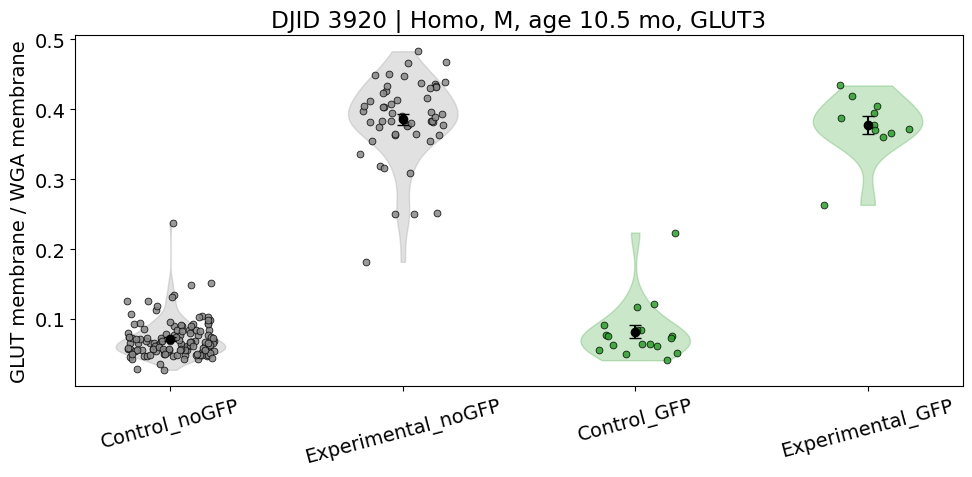

In [256]:
_ = plot_glut_violins_points_sem(T, spacing=0.7, width=0.33, name_of_protein = 'GLUT3')

# OLD CODE 

DJID 3920, Homo, M, age 10.5 months
Dark: 0 cells, 0 GFP+ = 0%
Light: 0 cells, 0 GFP+ = 0%
Effect size (no GFP): nan
No eGFP-positive cells present, skipping GFP effect size.


c:\Users\Luis\anaconda3\envs\T5_env\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Luis\anaconda3\envs\T5_env\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Luis\anaconda3\envs\T5_env\lib\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Luis\anaconda3\envs\T5_env\lib\site-packages\numpy\core\_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\Luis\anaconda3\envs\T5_env\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Luis\anaconda3\envs\T5_env\lib\site-packages\matplotlib\axes\_axes.py:1185: Runti

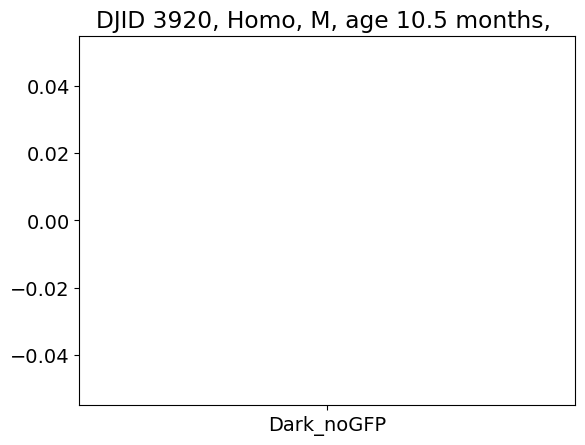

In [257]:
# Set response type
resp_type = 'glut1_membrane_over_wga_membrane'

animal_ids = T['DJID'].unique()

# Initialize storage
results = {
    'effect_size_noGFP': [],
    'effect_size_GFP': [],
    'genotype': [],
    'sex': [],
    'age': [],
    'animal_id': [],
    'n_cells': [],
    'frac_GFP': []
}

# Corrected calculate_ratios function
def calculate_ratios(df, ratio_type):
    if df.empty:
        return []
    if ratio_type == 'glut1_membrane_over_middle':
        denominator = df['GluT1_Middle_Integral'] * df['Length_um']
    elif ratio_type == 'glut1_membrane_over_wga_membrane':
        denominator = df['WGA_Top_Integral'] + df['WGA_Bottom_Integral']

    # Handle cases where the denominator might be zero
    with np.errstate(divide='ignore', invalid='ignore'):
        ratios = (df['GluT1_Top_Integral'] + df['GluT1_Bottom_Integral']) / denominator
        ratios = ratios.replace([np.inf, -np.inf], np.nan)  # Replace inf values with NaN
        return ratios.dropna().tolist()  # Drop NaN values and return as list

# Analysis loop
for a in animal_ids:
    T_thisAnimal = T[T['DJID'] == a]
    genotype, sex, age = T_thisAnimal.iloc[0][['Genotype', 'Sex', 'Age_Months']]
    N_cells = len(T_thisAnimal)

    T_dark = T_thisAnimal[T_thisAnimal['Experimental_Condition'] == 'Dark']
    T_light = T_thisAnimal[T_thisAnimal['Experimental_Condition'] == 'Light Flicker']

    T_dark_GFP, T_dark_noGFP = T_dark[T_dark['eGFP_Value'] > 0], T_dark[T_dark['eGFP_Value'] == 0]
    T_light_GFP, T_light_noGFP = T_light[T_light['eGFP_Value'] > 0], T_light[T_light['eGFP_Value'] == 0]

    frac_GFP = (len(T_dark_GFP) + len(T_light_GFP)) / N_cells if N_cells else 0

    print(f"DJID {a}, {genotype}, {sex}, age {age:.1f} months")
    print(f"Dark: {len(T_dark)} cells, {len(T_dark_GFP)} GFP+ = {100 * len(T_dark_GFP) / len(T_dark) if len(T_dark) else 0:.0f}%")
    print(f"Light: {len(T_light)} cells, {len(T_light_GFP)} GFP+ = {100 * len(T_light_GFP) / len(T_light) if len(T_light) else 0:.0f}%")
    
    ratios_dark_noGFP = calculate_ratios(T_dark_noGFP, resp_type)
    ratios_light_noGFP = calculate_ratios(T_light_noGFP, resp_type)
    ratios_dark_GFP = calculate_ratios(T_dark_GFP, resp_type)
    ratios_light_GFP = calculate_ratios(T_light_GFP, resp_type)

    response_vec_mean = [
        np.mean(ratios_dark_noGFP), np.mean(ratios_light_noGFP),
        np.mean(ratios_dark_GFP) if ratios_dark_GFP else np.nan, 
        np.mean(ratios_light_GFP) if ratios_light_GFP else np.nan
    ]
    response_vec_sd = [
        np.std(ratios_dark_noGFP), np.std(ratios_light_noGFP),
        np.std(ratios_dark_GFP) if ratios_dark_GFP else np.nan,
        np.std(ratios_light_GFP) if ratios_light_GFP else np.nan
    ]
    response_vec_sem = [
        np.std(ratios_dark_noGFP) / np.sqrt(len(ratios_dark_noGFP) - 1) if len(ratios_dark_noGFP) > 1 else np.nan,
        np.std(ratios_light_noGFP) / np.sqrt(len(ratios_light_noGFP) - 1) if len(ratios_light_noGFP) > 1 else np.nan,
        np.std(ratios_dark_GFP) / np.sqrt(len(ratios_dark_GFP) - 1) if len(ratios_dark_GFP) > 1 else np.nan,
        np.std(ratios_light_GFP) / np.sqrt(len(ratios_light_GFP) - 1) if len(ratios_light_GFP) > 1 else np.nan,
    ]

    # Calculate effect sizes
    effect_size_noGFP = (response_vec_mean[1] - response_vec_mean[0]) / np.mean([response_vec_sd[1], response_vec_sd[0]])
    effect_size_GFP = (response_vec_mean[3] - response_vec_mean[2]) / np.mean([response_vec_sd[3], response_vec_sd[2]]) if not np.isnan(response_vec_mean[2]) and not np.isnan(response_vec_mean[3]) else np.nan

    # Print effect sizes
    print(f"Effect size (no GFP): {effect_size_noGFP:.2f}")
    print(f"Effect size (GFP): {effect_size_GFP:.2f}" if not np.isnan(effect_size_GFP) else "No eGFP-positive cells present, skipping GFP effect size.")

    # Store results
    results['effect_size_noGFP'].append(effect_size_noGFP)
    results['effect_size_GFP'].append(effect_size_GFP)
    results['genotype'].append(genotype)
    results['sex'].append(sex)
    results['age'].append(age)
    results['animal_id'].append(a)
    results['n_cells'].append(N_cells)
    results['frac_GFP'].append(frac_GFP)

    # Plotting
    plt.bar(['Dark_noGFP', 'Light_noGFP'], response_vec_mean[0:2], color='gray', edgecolor='black')
    
    if len(ratios_dark_noGFP): plt.scatter(['Dark_noGFP'] * len(ratios_dark_noGFP), ratios_dark_noGFP, color='grey', edgecolors='black')
    if len(ratios_light_noGFP): plt.scatter(['Light_noGFP'] * len(ratios_light_noGFP), ratios_light_noGFP, color='grey', edgecolors='black')
    
    if not np.isnan(response_vec_mean[2]) and not np.isnan(response_vec_mean[3]):
        plt.bar(['Dark_GFP', 'Light_GFP'], response_vec_mean[2:4], color='green', edgecolor='black')
        if len(ratios_dark_GFP): plt.scatter(['Dark_GFP'] * len(ratios_dark_GFP), ratios_dark_GFP, color='green', edgecolor='black')
        if len(ratios_light_GFP): plt.scatter(['Light_GFP'] * len(ratios_light_GFP), ratios_light_GFP, color='green', edgecolor='black')

        plt.errorbar(['Dark_GFP', 'Light_GFP'], response_vec_mean[2:4], yerr=response_vec_sem[2:4], fmt='.', color='black', linewidth=2)

    plt.errorbar(['Dark_noGFP', 'Light_noGFP'], response_vec_mean[0:2], yerr=response_vec_sem[0:2], fmt='.', color='black', linewidth=2)

    plt.title(f"DJID {a}, {genotype}, {sex}, age {age:.1f} months, ")
    plt.show()

# Convert results to DataFrame
result_table = pd.DataFrame(results)
result_table = result_table.dropna(subset=['effect_size_noGFP'])


C:\Users\Luis\AppData\Local\Temp\ipykernel_18520\41355728.py:63: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Time_Condition', y='Mean', data=plot_df, color='blue' if genotype_to_plot == 'het' else 'red', ci=None)
c:\Users\Luis\anaconda3\envs\T5_env\lib\site-packages\matplotlib\axes\_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
c:\Users\Luis\anaconda3\envs\T5_env\lib\site-packages\matplotlib\axes\_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


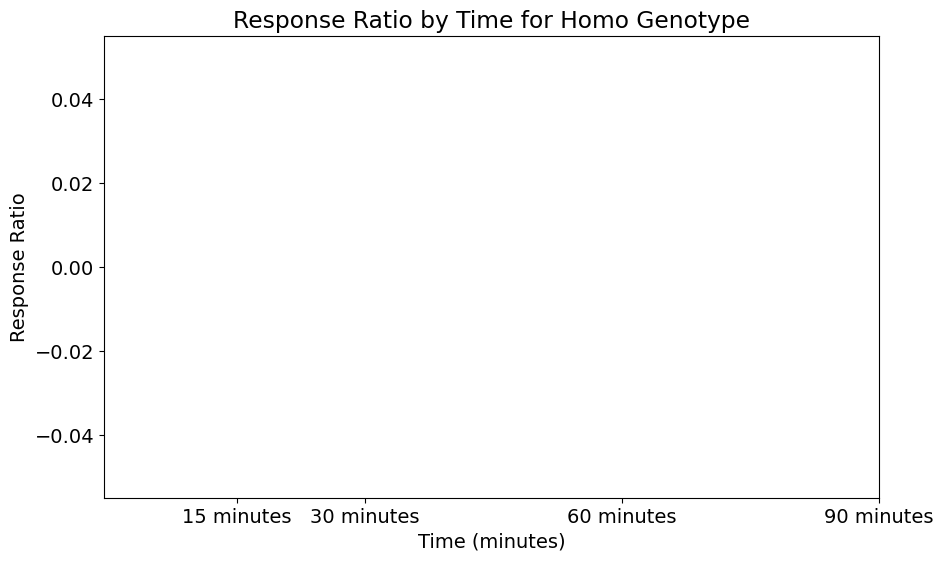

In [258]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming T is your DataFrame and it now has a 'Time_Condition' column with 15, 30, 60, 90 minutes.
# Also assuming 'Genotype' column has 'het' and 'homo'

# Set response type
resp_type = 'glut1_membrane_over_wga_membrane'

# Choose the genotype to plot ('het' or 'homo')
genotype_to_plot = 'homo'  # Change this to 'het' to plot for the 'het' genotype

# Function to calculate ratios
def calculate_ratios(df, ratio_type):
    if df.empty:
        return []
    if ratio_type == 'glut1_membrane_over_middle':
        denominator = df['GluT1_Middle_Integral'] * df['Length_um']
    elif ratio_type == 'glut1_membrane_over_wga_membrane':
        denominator = df['WGA_Top_Integral'] + df['WGA_Bottom_Integral']

    with np.errstate(divide='ignore', invalid='ignore'):
        ratios = (df['GluT1_Top_Integral'] + df['GluT1_Bottom_Integral']) / denominator
        ratios = ratios.replace([np.inf, -np.inf], np.nan)
        return ratios.dropna().tolist()

# Initialize storage for plotting
plot_data = {
    'Time_Condition': [],
    'Mean': [],
    'SEM': [],
    'Ratios': []
}

# Define the time slots
time_slots = [15, 30, 60, 90]

# Loop over time slots
for time in time_slots:
    T_time_genotype = T[(T['Time_Condition'] == time) & (T['Genotype'] == genotype_to_plot)]
    ratios = calculate_ratios(T_time_genotype, resp_type)

    plot_data['Time_Condition'].append(time)  # Always append the time to ensure placeholders exist

    if ratios:
        plot_data['Mean'].append(np.mean(ratios))
        plot_data['SEM'].append(np.std(ratios) / np.sqrt(len(ratios)))
        plot_data['Ratios'].append(ratios)
    else:
        plot_data['Mean'].append(np.nan)
        plot_data['SEM'].append(np.nan)
        plot_data['Ratios'].append([])

# Convert plot data to DataFrame
plot_df = pd.DataFrame(plot_data)

# Plotting
plt.figure(figsize=(10, 6))

# Create bar plot with placeholders for missing data
sns.barplot(x='Time_Condition', y='Mean', data=plot_df, color='blue' if genotype_to_plot == 'het' else 'red', ci=None)

# Overlay scatter points, aligning them with the bar positions
for i, time in enumerate(plot_df['Time_Condition']):
    if plot_df.loc[i, 'Ratios']:
        plt.scatter([time] * len(plot_df.loc[i, 'Ratios']), plot_df.loc[i, 'Ratios'], color='black')

# Add error bars
plt.errorbar(x=plot_df['Time_Condition'], y=plot_df['Mean'], yerr=plot_df['SEM'], fmt='none', color='black', capsize=5)

# Ensure all time conditions have a placeholder on the x-axis
plt.xticks(ticks=[15, 30, 60, 90], labels=[f'{t} minutes' for t in time_slots])

plt.xlabel('Time (minutes)')
plt.ylabel('Response Ratio')
plt.title(f'Response Ratio by Time for {genotype_to_plot.capitalize()} Genotype')
plt.show()


# Simulating Time Data

In [259]:
from numpy import random

In [260]:
sim_data = pd.DataFrame()

random.seed(20)
obs_len = 1000

def generate_true_false_array(len, true_percentage=0.2):
    num_true = int(true_percentage * len)
    arr = np.array([1] * num_true + [0] * (len - num_true))
    np.random.shuffle(arr)
    return arr

sim_data['Exp_Condition'] = random.choice(['Light Flicker', 'Dark'], obs_len)
sim_data['Time_Condition'] = random.choice(['15', '30', '60', '90'], obs_len)
sim_data['Ratios'] = np.abs(random.normal(0, 1, obs_len))
sim_data['eGFP_Value'] = generate_true_false_array(obs_len)

mice = [
    {'Genotype': 'homo', 'Sex': 'Male', 'Age': '7'},
    {'Genotype': 'het', 'Sex': 'Male', 'Age': '12'},
    {'Genotype': 'het', 'Sex': 'Female', 'Age': '4'}
]

# Randomly assign each observation to a mouse
assigned_mice = random.choice(mice, obs_len)

# Add the mouse metadata to sim_data
sim_data['Genotype'] = [mouse['Genotype'] for mouse in assigned_mice]
sim_data['Sex'] = [mouse['Sex'] for mouse in assigned_mice]
sim_data['Age'] = [mouse['Age'] for mouse in assigned_mice]

sim_data.head()

,Exp_Condition,Time_Condition,Ratios,eGFP_Value,Genotype,Sex,Age
0,Dark,30,0.529805,0,homo,Male,7
1,Light Flicker,90,1.476067,0,het,Male,12
2,Dark,15,0.223554,0,het,Male,12
3,Dark,60,0.900479,0,homo,Male,7
4,Light Flicker,15,0.515764,0,homo,Male,7


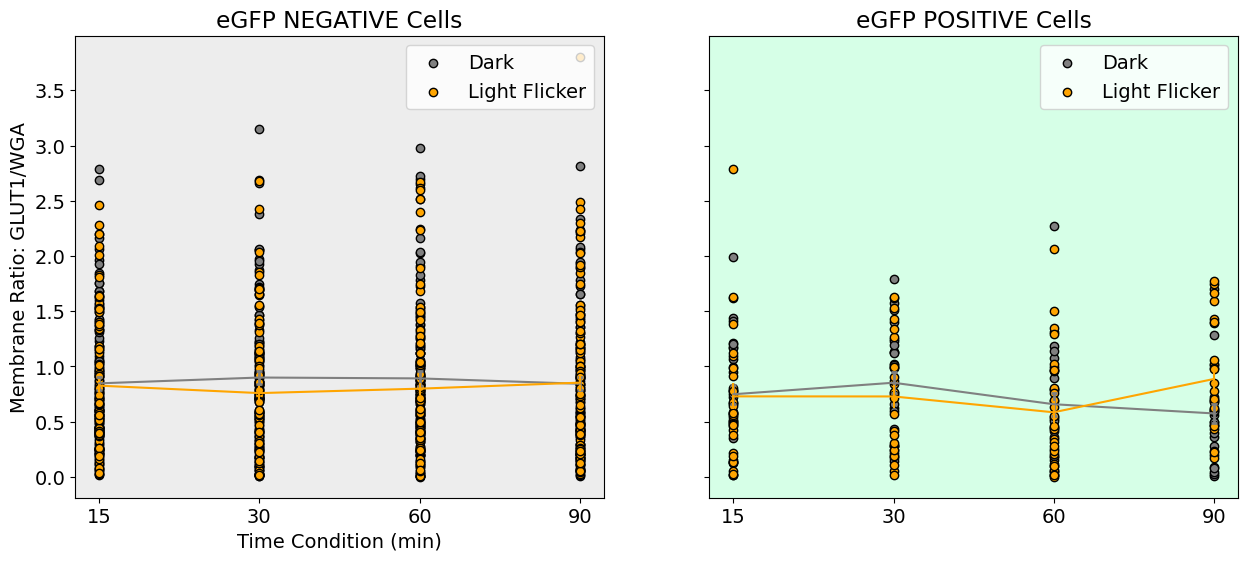

In [261]:
desired_order = ['15', '30', '60', '90']
sim_data['Time_Condition'] = pd.Categorical(sim_data['Time_Condition'], categories=desired_order, ordered=True)
sim_data = sim_data.sort_values('Time_Condition')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey = True)  # 2 rows, 1 column


sim_data_eGFP = sim_data.loc[sim_data['eGFP_Value'] == 1]
sim_data_noneGFP = sim_data.loc[sim_data['eGFP_Value'] == 0]


ax1.scatter(data = sim_data_noneGFP.loc[sim_data_noneGFP['Exp_Condition'] == 'Dark'], x = 'Time_Condition', y = 'Ratios',
            label = 'Dark', c = 'grey', edgecolors = 'black')
ax1.scatter(data = sim_data_noneGFP.loc[sim_data_noneGFP['Exp_Condition'] == 'Light Flicker'], x = 'Time_Condition', y = 'Ratios',
            label = 'Light Flicker', c = 'orange', edgecolors = 'black')

ax1.legend(loc = 'upper right')

ax2.scatter(data = sim_data_eGFP.loc[sim_data_eGFP['Exp_Condition'] == 'Dark'], x = 'Time_Condition', y = 'Ratios',
            label = 'Dark', c = 'grey', edgecolors = 'black')
ax2.scatter(data = sim_data_eGFP.loc[sim_data_eGFP['Exp_Condition'] == 'Light Flicker'], x = 'Time_Condition', y = 'Ratios',
            label = 'Light Flicker', c = 'orange', edgecolors = 'black')

ax2.legend(loc = 'upper right')

### Code for errorbars

grouped_data_noneGFP = sim_data_noneGFP.groupby(['Exp_Condition', 'Time_Condition']).agg(
    Mean_Ratio=('Ratios', 'mean'),
    Std_Error=('Ratios', lambda x: np.std(x) / np.sqrt(len(x)))
).reset_index()

ax1.errorbar(data = grouped_data_noneGFP.loc[grouped_data_noneGFP['Exp_Condition'] == 'Dark'], x = 'Time_Condition', y = 'Mean_Ratio', yerr= 'Std_Error',
             label = None, c = 'Grey', capsize = 2, capthick = 2, elinewidth = 2)
ax1.errorbar(data = grouped_data_noneGFP.loc[grouped_data_noneGFP['Exp_Condition'] == 'Light Flicker'], x = 'Time_Condition', y = 'Mean_Ratio', yerr= 'Std_Error',
             label = None, c = 'orange')

grouped_data_eGFP = sim_data_eGFP.groupby(['Exp_Condition', 'Time_Condition']).agg(
    Mean_Ratio=('Ratios', 'mean'),
    Std_Error=('Ratios', lambda x: np.std(x) / np.sqrt(len(x)))
).reset_index()

ax2.errorbar(data = grouped_data_eGFP.loc[grouped_data_eGFP['Exp_Condition'] == 'Dark'], x = 'Time_Condition', y = 'Mean_Ratio', yerr= 'Std_Error',
             label = None, c = 'Grey', capsize = 2, capthick = 2, elinewidth = 2)
ax2.errorbar(data = grouped_data_eGFP.loc[grouped_data_eGFP['Exp_Condition'] == 'Light Flicker'], x = 'Time_Condition', y = 'Mean_Ratio', yerr= 'Std_Error',
             label = None, c = 'orange')

### Ax title and background
ax1.set_title('eGFP NEGATIVE Cells')
ax1.set_facecolor('#ededed')
ax1.set_ylabel('Membrane Ratio: GLUT1/WGA')
ax1.set_xlabel('Time Condition (min)')

ax2.set_title('eGFP POSITIVE Cells')
ax2.set_facecolor('#d6ffe7')

In [262]:
sim_data = T.copy()
sim_data.rename(columns = {'Experimental_Condition': 'Exp_Condition'})

,mask_id,Slice_Seperation,file_name,DJID,Sex,Eye,Age_Months,Genotype,Exp_Condition,Time_Condition,...,WGA_Top_Integral,GLUT1_Top_Integral,WGA_Bottom_Integral,GLUT1_Bottom_Integral,GLUT1_Top_Surface_Integral,GLUT1_Bot_Surface_Integral,WGA_Top_Surface_Integral,WGA_Bot_Surface_Integral,Top_Surface_Ratio,Bot_Surface_Ratio
90,91,0.15,3920L_GLUT3_WGA594_0002.nd2,3920,M,L,10.5,Homo,Control,0,...,646.995960,31.562290,722.930640,91.606734,130.787879,190.694949,1639.500337,1321.812795,0.079773,0.144268
91,92,0.15,3920L_GLUT3_WGA594_0002.nd2,3920,M,L,10.5,Homo,Control,0,...,1859.712749,121.229014,NaN,NaN,201.228751,NaN,3476.266789,NaN,0.057886,NaN
92,93,0.15,3920L_GLUT3_WGA594_0002.nd2,3920,M,L,10.5,Homo,Control,0,...,605.303759,91.558596,739.720287,209.259812,601.856274,643.944168,1856.278883,1505.739359,0.324227,0.427660
93,94,0.15,3920L_GLUT3_WGA594_0002.nd2,3920,M,L,10.5,Homo,Control,0,...,733.429533,39.112747,713.855280,56.570888,161.839714,114.106857,1978.378208,1389.479596,0.081804,0.082122
94,95,0.15,3920L_GLUT3_WGA594_0002.nd2,3920,M,L,10.5,Homo,Control,0,...,738.024843,25.870931,916.820103,69.647915,130.982581,182.629926,2218.089377,1842.812393,0.059052,0.099104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,0.15,3920R_GLUT3_WGA594_0001.nd2,3920,M,R,10.5,Homo,Experimental,30,...,NaN,NaN,130.853737,56.622745,NaN,119.529639,NaN,257.122423,NaN,0.464874
296,297,0.15,3920R_GLUT3_WGA594_0001.nd2,3920,M,R,10.5,Homo,Experimental,30,...,NaN,NaN,139.417489,62.616714,NaN,126.599436,NaN,267.878702,NaN,0.472600
297,298,0.15,3920R_GLUT3_WGA594_0001.nd2,3920,M,R,10.5,Homo,Experimental,30,...,NaN,NaN,144.063420,62.285642,NaN,156.059868,NaN,284.292491,NaN,0.548941
298,299,0.15,3920R_GLUT3_WGA594_0001.nd2,3920,M,R,10.5,Homo,Experimental,30,...,NaN,NaN,157.692335,67.780239,NaN,138.077356,NaN,301.374473,NaN,0.458159


KeyError: 'Exp_Condition'

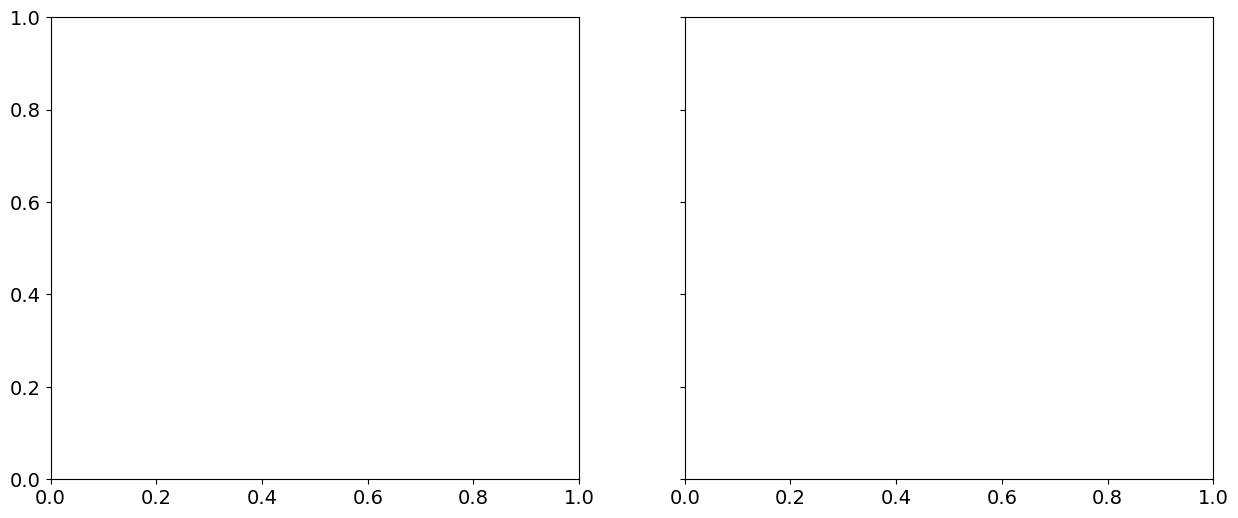

In [263]:
desired_order = ['15', '30', '60', '90']
sim_data['Time_Condition'] = pd.Categorical(sim_data['Time_Condition'], categories=desired_order, ordered=True)
sim_data = sim_data.sort_values('Time_Condition')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey = True)  # 2 rows, 1 column


sim_data_eGFP = sim_data.loc[sim_data['eGFP_Value'] == 1]
sim_data_noneGFP = sim_data.loc[sim_data['eGFP_Value'] == 0]


ax1.scatter(data = sim_data_noneGFP.loc[sim_data_noneGFP['Exp_Condition'] == 'Dark'], x = 'Time_Condition', y = 'Ratios',
            label = 'Dark', c = 'grey', edgecolors = 'black')
ax1.scatter(data = sim_data_noneGFP.loc[sim_data_noneGFP['Exp_Condition'] == 'Light Flicker'], x = 'Time_Condition', y = 'Ratios',
            label = 'Light Flicker', c = 'orange', edgecolors = 'black')

ax1.legend(loc = 'upper right')

ax2.scatter(data = sim_data_eGFP.loc[sim_data_eGFP['Exp_Condition'] == 'Dark'], x = 'Time_Condition', y = 'Ratios',
            label = 'Dark', c = 'grey', edgecolors = 'black')
ax2.scatter(data = sim_data_eGFP.loc[sim_data_eGFP['Exp_Condition'] == 'Light Flicker'], x = 'Time_Condition', y = 'Ratios',
            label = 'Light Flicker', c = 'orange', edgecolors = 'black')

ax2.legend(loc = 'upper right')

### Code for errorbars

grouped_data_noneGFP = sim_data_noneGFP.groupby(['Exp_Condition', 'Time_Condition']).agg(
    Mean_Ratio=('Ratios', 'mean'),
    Std_Error=('Ratios', lambda x: np.std(x) / np.sqrt(len(x)))
).reset_index()

ax1.errorbar(data = grouped_data_noneGFP.loc[grouped_data_noneGFP['Exp_Condition'] == 'Dark'], x = 'Time_Condition', y = 'Mean_Ratio', yerr= 'Std_Error',
             label = None, c = 'Grey', capsize = 2, capthick = 2, elinewidth = 2)
ax1.errorbar(data = grouped_data_noneGFP.loc[grouped_data_noneGFP['Exp_Condition'] == 'Light Flicker'], x = 'Time_Condition', y = 'Mean_Ratio', yerr= 'Std_Error',
             label = None, c = 'orange')

grouped_data_eGFP = sim_data_eGFP.groupby(['Exp_Condition', 'Time_Condition']).agg(
    Mean_Ratio=('Ratios', 'mean'),
    Std_Error=('Ratios', lambda x: np.std(x) / np.sqrt(len(x)))
).reset_index()

ax2.errorbar(data = grouped_data_eGFP.loc[grouped_data_eGFP['Exp_Condition'] == 'Dark'], x = 'Time_Condition', y = 'Mean_Ratio', yerr= 'Std_Error',
             label = None, c = 'Grey', capsize = 2, capthick = 2, elinewidth = 2)
ax2.errorbar(data = grouped_data_eGFP.loc[grouped_data_eGFP['Exp_Condition'] == 'Light Flicker'], x = 'Time_Condition', y = 'Mean_Ratio', yerr= 'Std_Error',
             label = None, c = 'orange')

### Ax title and background
ax1.set_title('eGFP NEGATIVE Cells')
ax1.set_facecolor('#ededed')
ax1.set_ylabel('Membrane Ratio: GLUT1/WGA')
ax1.set_xlabel('Time Condition (min)')

ax2.set_title('eGFP POSITIVE Cells')
ax2.set_facecolor('#d6ffe7')